# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Daffa Aufa Afif    |5054251022|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [136]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll)
import pandas as pd # Menyipan datanya nanti
import numpy as np # kalkulasi math
import matplotlib.pyplot as plt # visualisasi
import seaborn as sns # visualisasi2
import os # buat api kaggle
from google.colab import files
from dotenv import load_dotenv
from scipy import stats #buat ngilangin outlier nantinya
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Or MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from imblearn.over_sampling import SMOTE

In [5]:
# Upload the api.txt file
uploaded = files.upload()

# Check if the file was uploaded
if 'api.txt' in uploaded:
    # Create the .env directory if it doesn't exist
    env_dir = './.env'
    if not os.path.exists(env_dir):
        os.makedirs(env_dir)

    # Move the uploaded file to the .env directory
    with open(os.path.join(env_dir, 'api.txt'), 'wb') as f:
        f.write(uploaded['api.txt'])
    print("api.txt uploaded and moved to .env/api.txt")

    # Delete the original api.txt file from the current directory
    os.remove('api.txt')
else:
    print("api.txt was not uploaded.")

Saving api.txt to api.txt
api.txt uploaded and moved to .env/api.txt


In [6]:
# Load the environment variables from the .env file
load_dotenv('./.env/api.txt')

# Verify the credentials were read successfully
if os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
    print("Kaggle credentials loaded successfully from .env file!")
    print("Kaggle Username:", os.environ.get('KAGGLE_USERNAME'))
else:
    print("Failed to load credentials. check your variable names.")


Kaggle credentials loaded successfully from .env file!
Kaggle Username: daffaaufaafif


In [7]:
# Replace with your actual Kaggle dataset command
# Create a data folder (the -p flag ensures it won't crash if the folder already exists)
!mkdir -p data
#  Download the dataset directly into the data folder using the -p flag
!kaggle datasets download yasserh/wine-quality-dataset -p data

# Unzip the downloaded files
!unzip data/*.zip -d data
!rm data/*.zip

Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
License(s): CC0-1.0
100% 21.5k/21.5k [00:00<00:00, 31.8MB/s]

Archive:  data/wine-quality-dataset.zip
  inflating: data/WineQT.csv         


In [221]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
DATASET_NAME= "WineQT.csv"
DATASET_PATH = os.path.join('data', DATASET_NAME)
data = pd.read_csv(DATASET_PATH)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [222]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [223]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [224]:
#Attribut 'Id' tidak dibutuhkan
data = data.drop('Id', axis=1)

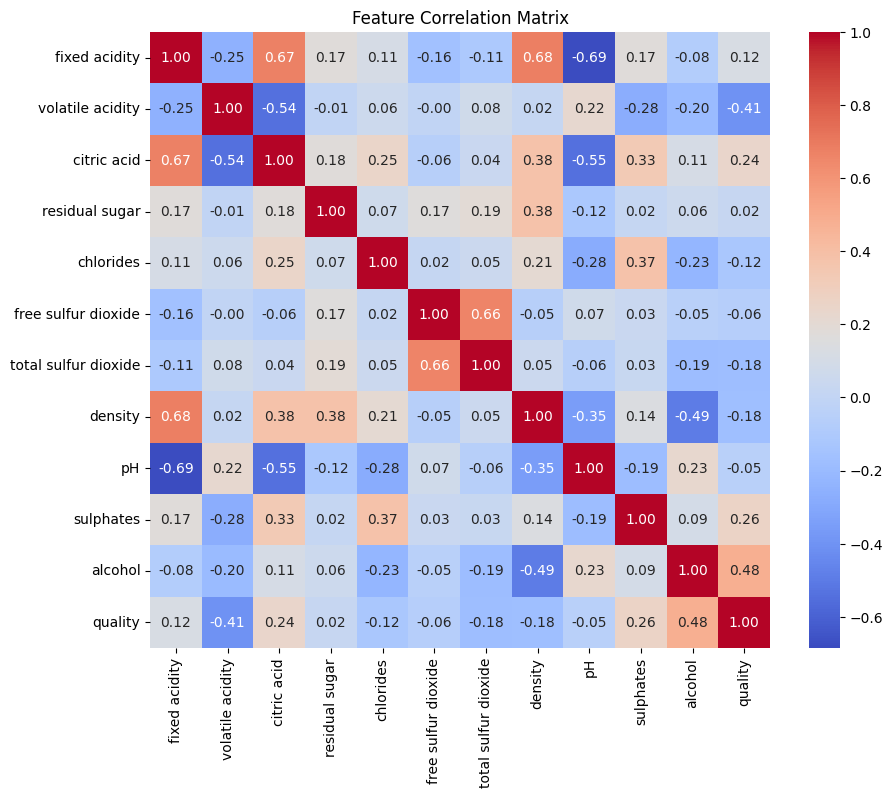

In [225]:
# Tampilkan Korelasi Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

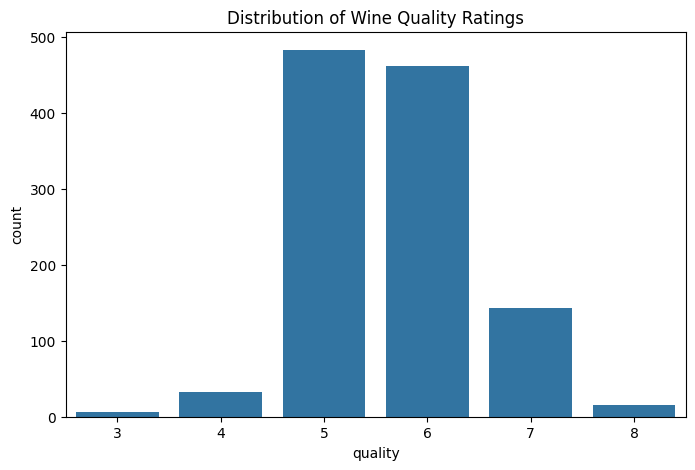

In [226]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='quality')
plt.title('Distribution of Wine Quality Ratings')
plt.show()

Dari distribusi, diketahui dataset tidak balance(Imbalance)

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan.

In [227]:
data.groupby('quality').count()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,6,6,6,6,6,6,6,6,6,6,6
4,33,33,33,33,33,33,33,33,33,33,33
5,483,483,483,483,483,483,483,483,483,483,483
6,462,462,462,462,462,462,462,462,462,462,462
7,143,143,143,143,143,143,143,143,143,143,143
8,16,16,16,16,16,16,16,16,16,16,16


In [228]:
#credit: https://www.kaggle.com/code/qusaybtoush1990/wine-quality
ave_qu = data.groupby("quality").mean()
ave_qu

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.450000,0.897500,0.211667,2.666667,0.105333,8.166667,24.500000,0.997682,3.361667,0.550000,9.691667
4,7.809091,0.700000,0.165758,2.566667,0.094788,14.848485,40.606061,0.996669,3.391212,0.637879,10.260606
5,8.161077,0.585280,0.240124,2.540476,0.091770,16.612836,55.299172,0.997073,3.302091,0.613375,9.902277
6,8.317749,0.504957,0.263680,2.444805,0.085281,15.215368,39.941558,0.996610,3.323788,0.676537,10.655339
7,8.851049,0.393671,0.386573,2.760140,0.075217,14.538462,37.489510,0.996071,3.287133,0.743566,11.482634
8,8.806250,0.410000,0.432500,2.643750,0.070187,11.062500,29.375000,0.995553,3.240625,0.766250,11.937500


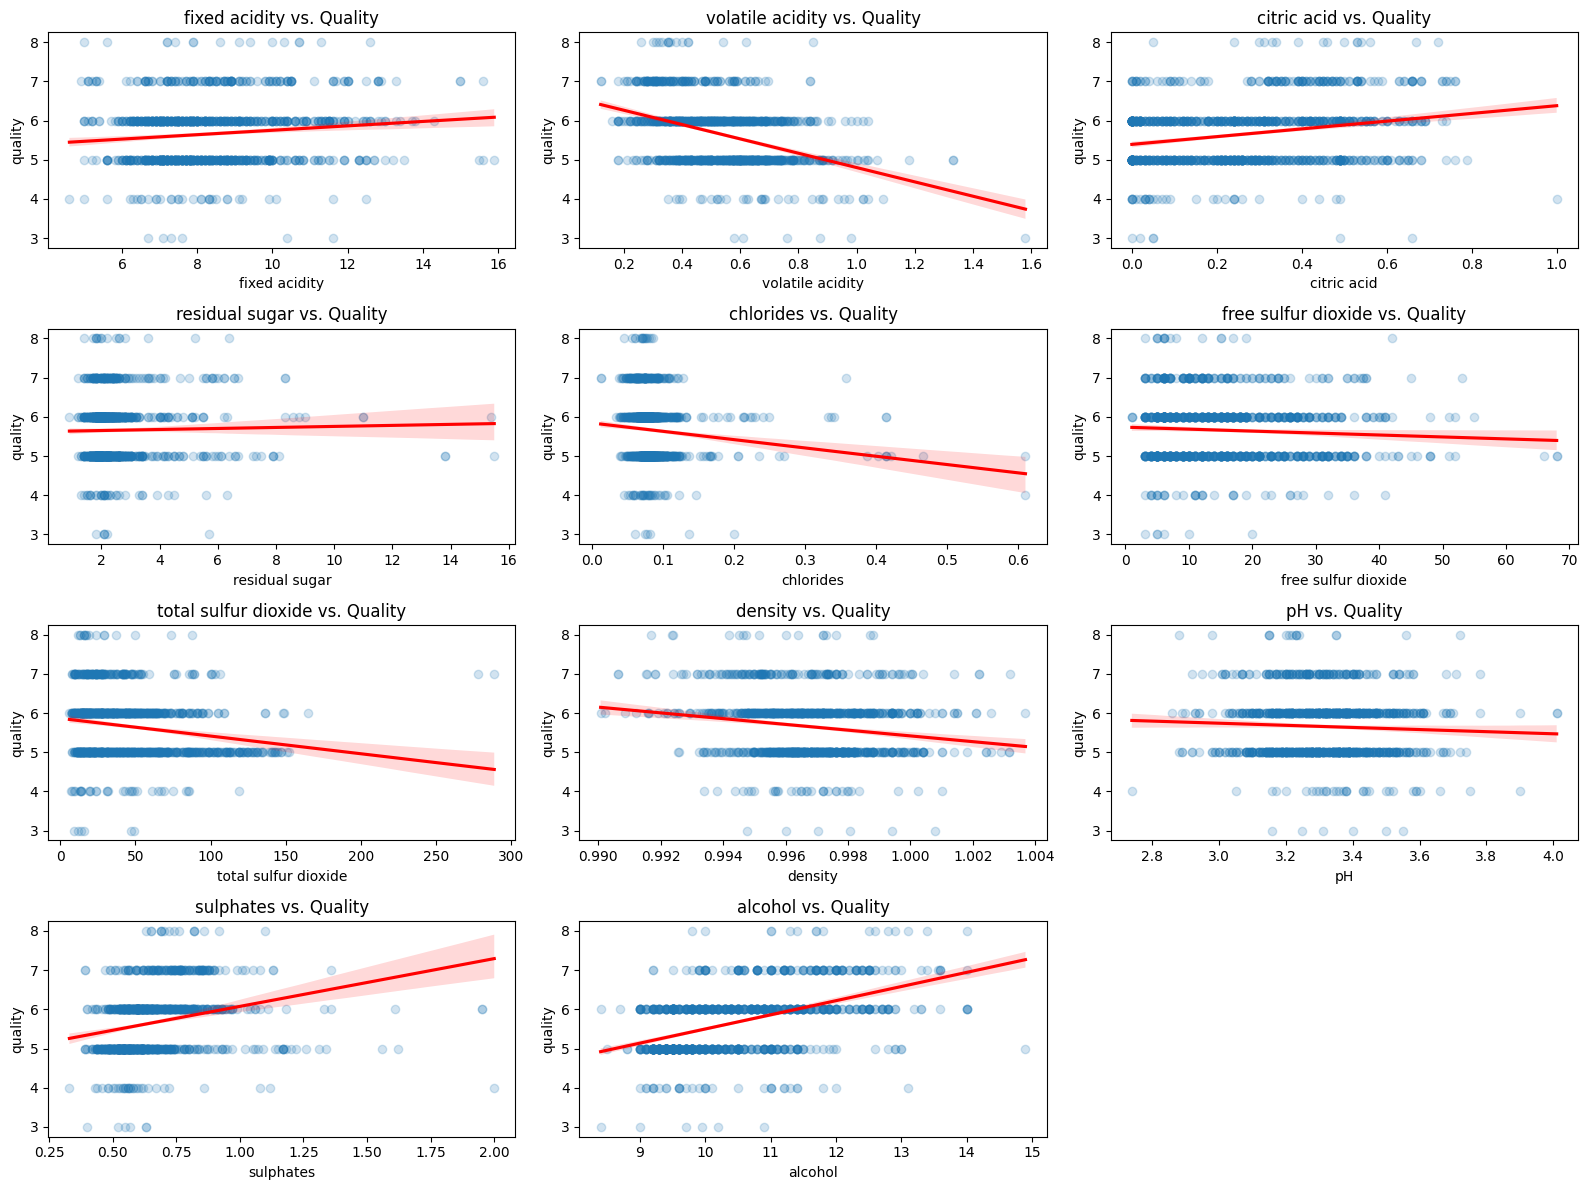

In [229]:
features = data.columns.drop('quality')

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(
        data=data,
        x=col,
        y='quality',
        ax=axes[i],
        scatter_kws={'alpha': 0.2},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f'{col} vs. Quality')

if len(features) < len(axes):
    fig.delaxes(axes[-1]) # Drops the 12th empty subplot slot

plt.tight_layout()
plt.show()

<Axes: xlabel='quality'>

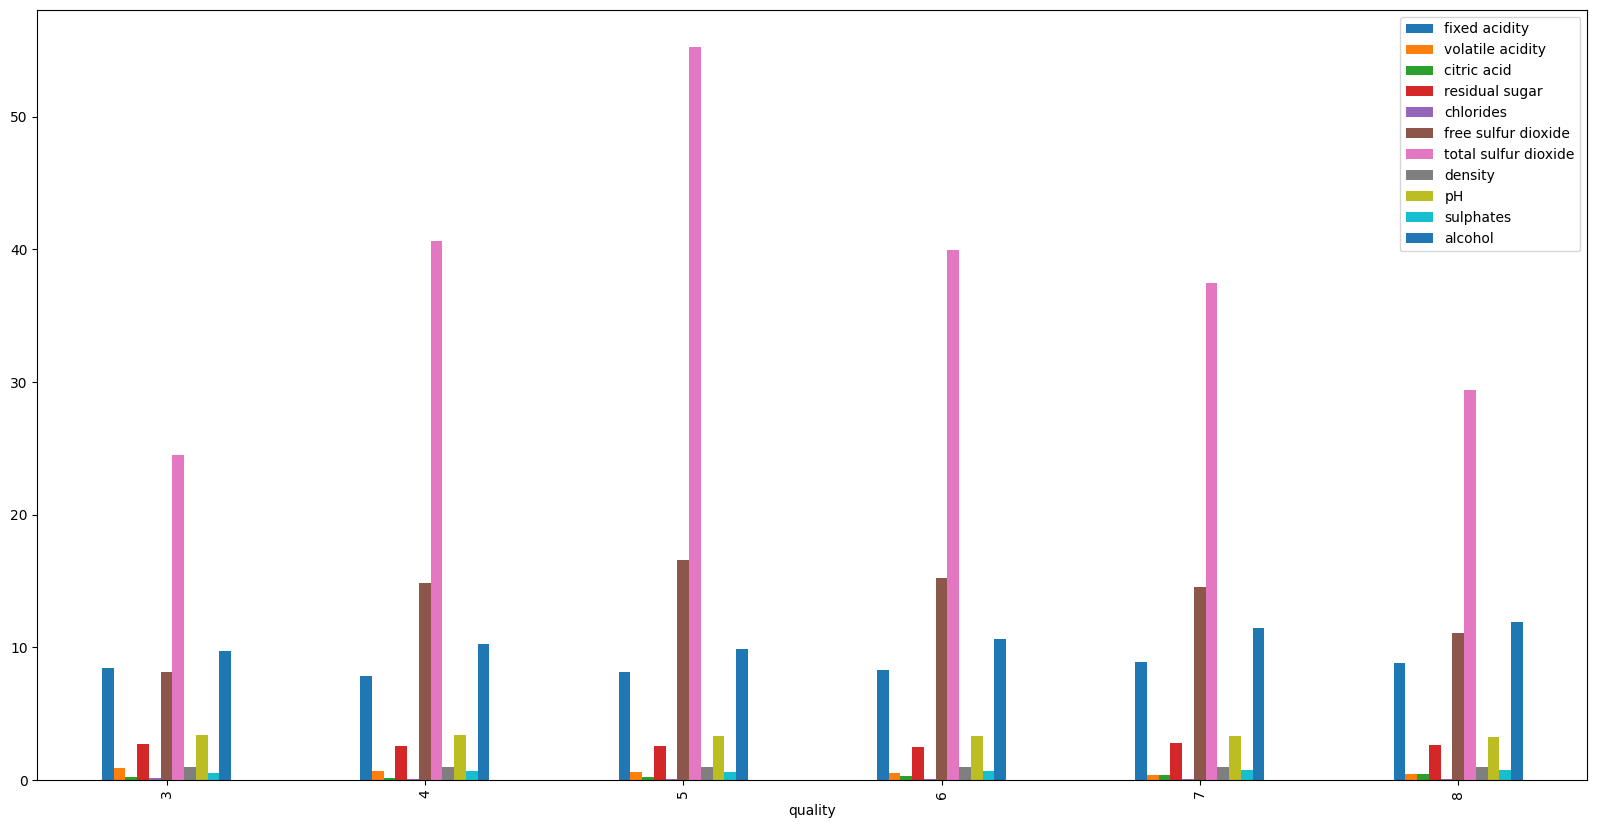

In [230]:
ave_qu.plot(kind="bar",figsize=(20,10))

In [231]:
spearman_corr = data.corr(method='spearman')['quality'].sort_values(ascending=False)
print(spearman_corr)

quality                 1.000000
alcohol                 0.495439
sulphates               0.393681
citric acid             0.222882
fixed acidity           0.103887
residual sugar          0.030614
pH                     -0.033205
free sulfur dioxide    -0.059213
density                -0.176505
chlorides              -0.193814
total sulfur dioxide   -0.194570
volatile acidity       -0.397784
Name: quality, dtype: float64


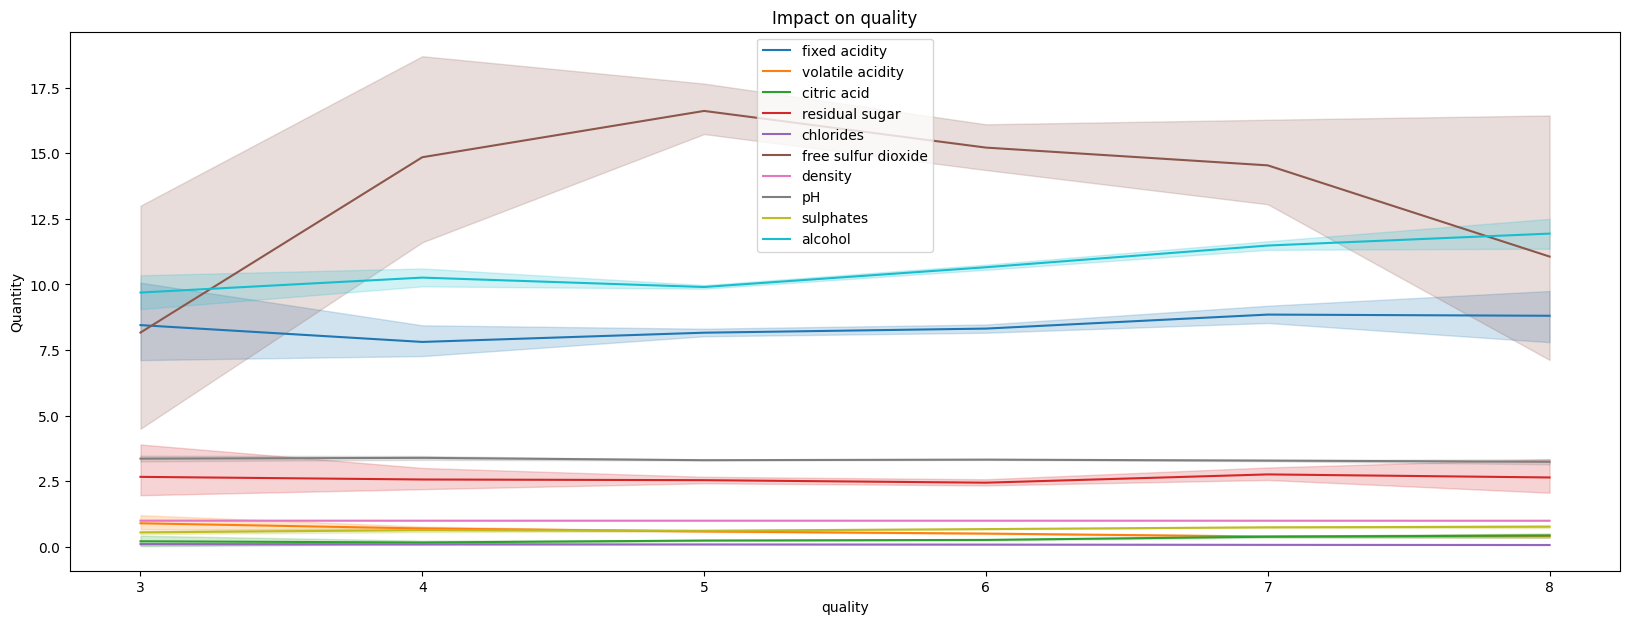

In [232]:
# let see effect some of elements on the quality - details
plt.figure(figsize=(20,7))
exclude = ave_qu.drop("total sulfur dioxide", axis=1)
for col in exclude.columns:
  sns.lineplot(data=data, x="quality",y=col,label=col)
plt.ylabel("Quantity")
plt.title("Impact on quality")
plt.legend()
plt.show()
# credit: https://www.kaggle.com/code/qusaybtoush1990/wine-quality

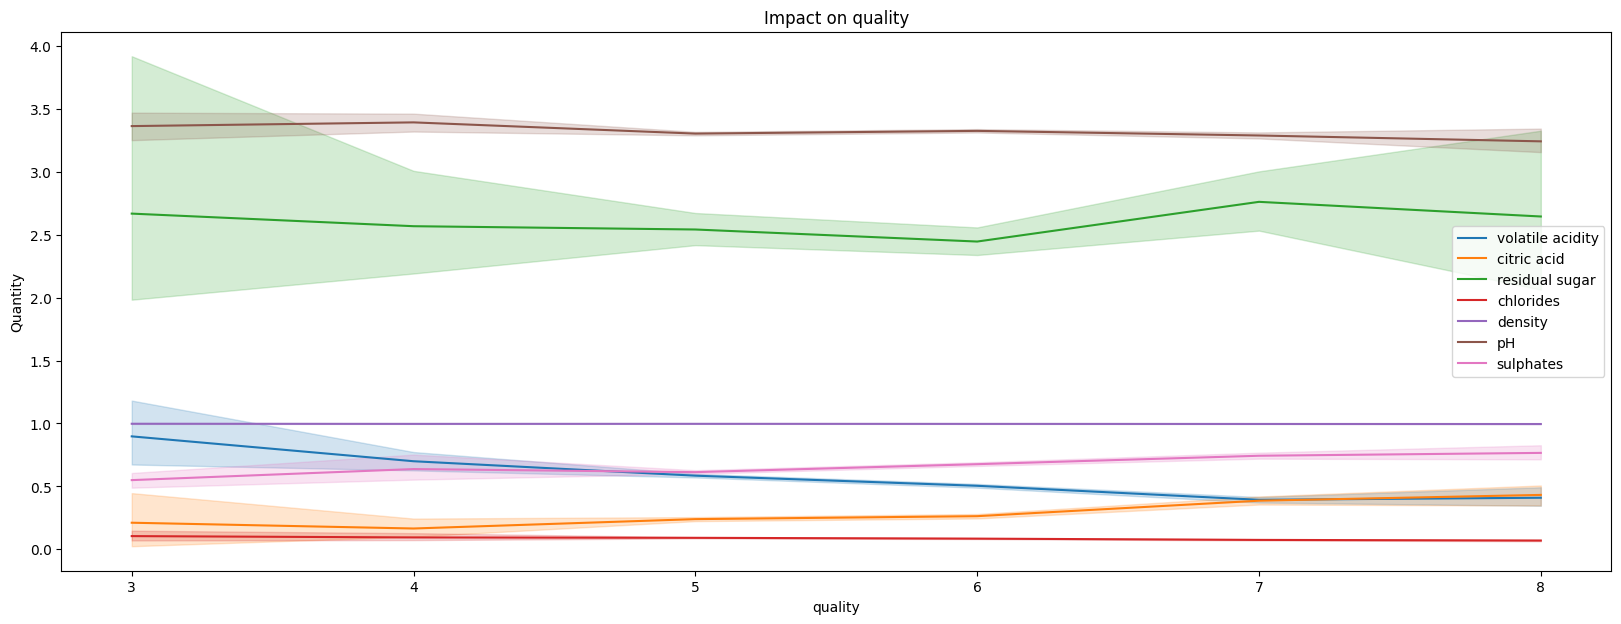

In [233]:
plt.figure(figsize=(20,7))
exclude = exclude.drop(columns=["free sulfur dioxide", "alcohol", "fixed acidity"], axis=1)
for col in exclude.columns:
  sns.lineplot(data=data, x="quality",y=col,label=col)
plt.ylabel("Quantity")
plt.title("Impact on quality")
plt.legend()
plt.show()

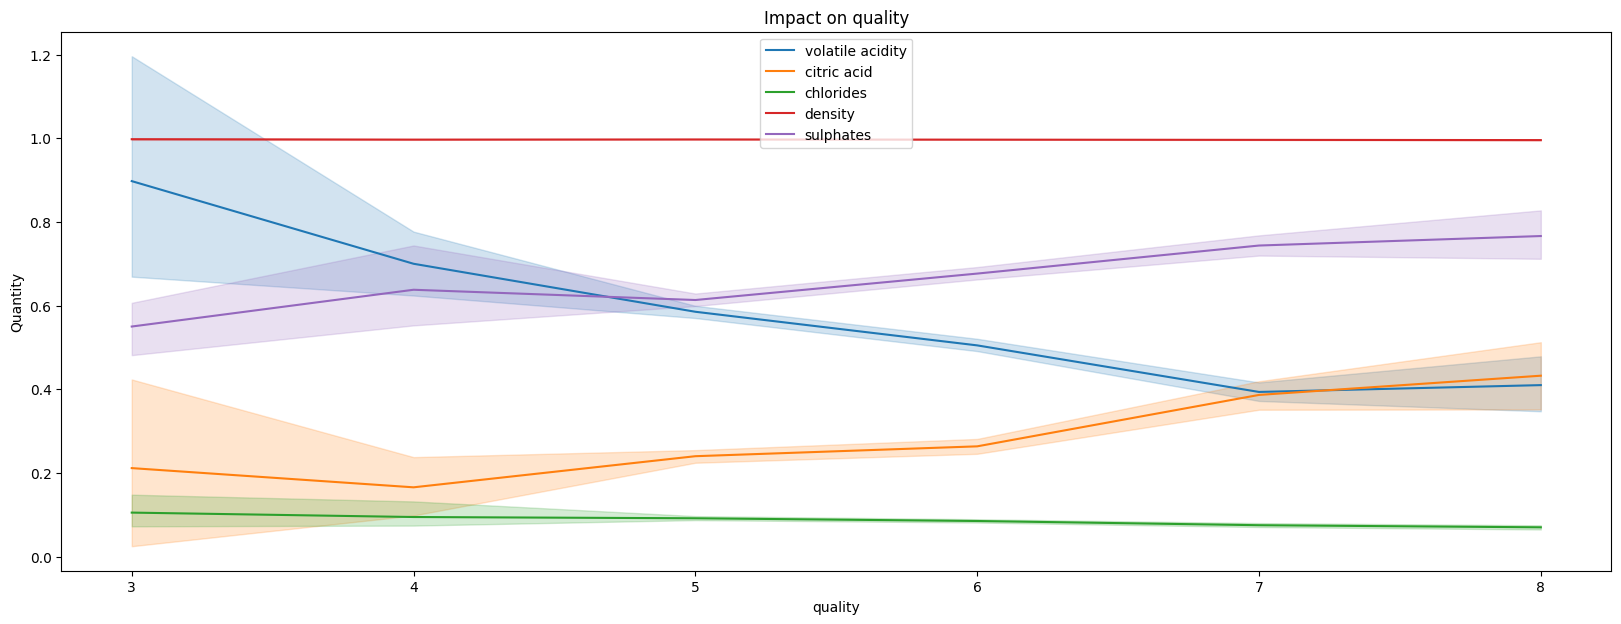

In [234]:
plt.figure(figsize=(20,7))
exclude = exclude.drop(columns=["pH", "residual sugar"], axis=1)
for col in exclude.columns:
  sns.lineplot(data=data, x="quality",y=col,label=col)
plt.ylabel("Quantity")
plt.title("Impact on quality")
plt.legend()
plt.show()

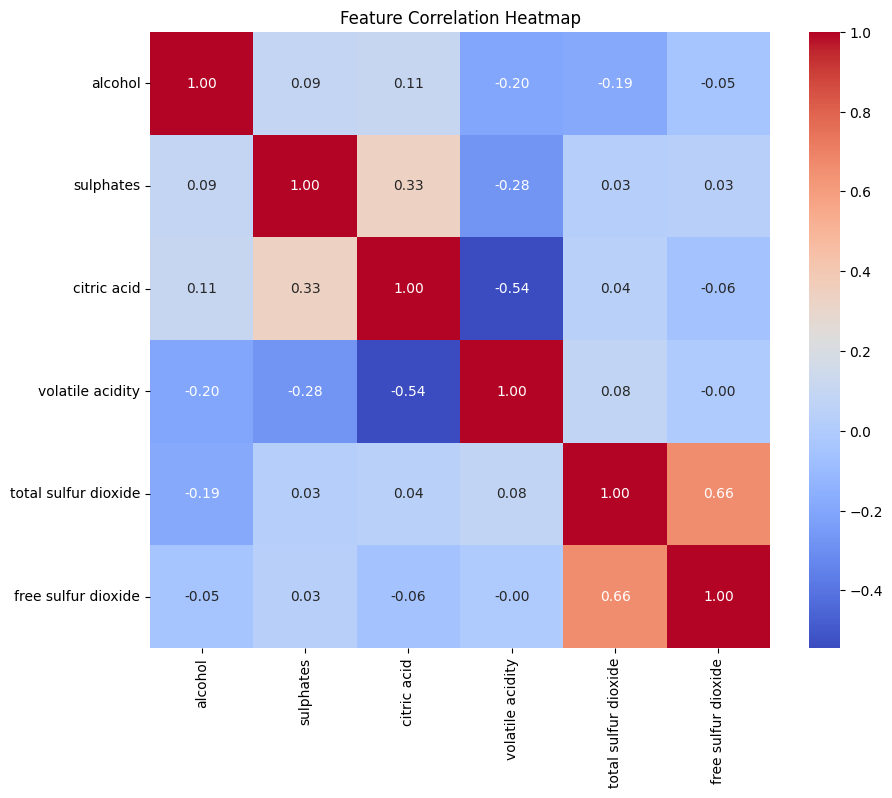

In [235]:
features = [
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'total sulfur dioxide',
    'free sulfur dioxide'
]
df_focus = data[features].copy()
corr = df_focus.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Dari data diatas, dapat diasumsikan bahwa feature yang paling berdampak pada kualitas adalah:
* Alcohol
* Sulphates
* Citric acid
* Volatile acidity
* Total sulfur dioxide
* Free sulfur dioxide

Namun, korelasi antara Total sulfur dioxide dan free sulfur dioxide terlihat memiliki korelasi yang kuat. Menurut Vinmetrica(https://vinmetrica.com/free-so2-and-total-so2/), Sulfur dioxide(SO2) digunakan untuk melindungi wine dari efek negatif oksigen dan mikroorganisme, Free SO2 penting untuk menentukan kemampuan bertahan lama wine, dan total SO2 biasanya tidak terlalu penting karena dipakai untuk memenuhi syarat ekspor. Tapi, kedua fitur tersebut masih dipakai sebagai tolak ukur Vinmetrica's SC-100A dan SC-300. Maka dari itu, Free SO2 dan Total SO2 akan tetap digukan bersamaan.

# 2. Preprocessing




In [236]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
data.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [237]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [238]:
data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.29,1.74,4.60,7.10,7.90,9.10,15.90
volatile acidity,1018.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1018.0,0.27,0.20,0.00,0.09,0.25,0.42,1.00
residual sugar,1018.0,2.52,1.31,0.90,1.90,2.20,2.60,15.50
chlorides,1018.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1018.0,15.65,10.18,1.00,7.00,13.00,21.00,68.00
total sulfur dioxide,1018.0,46.33,33.12,6.00,21.00,38.00,62.00,289.00
density,1018.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1018.0,3.31,0.16,2.74,3.21,3.31,3.40,4.01
sulphates,1018.0,0.66,0.17,0.33,0.55,0.62,0.72,2.00


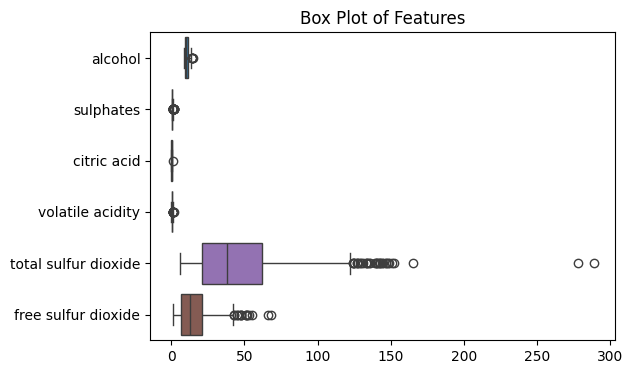

Original rows: 1018, Cleaned rows: 969


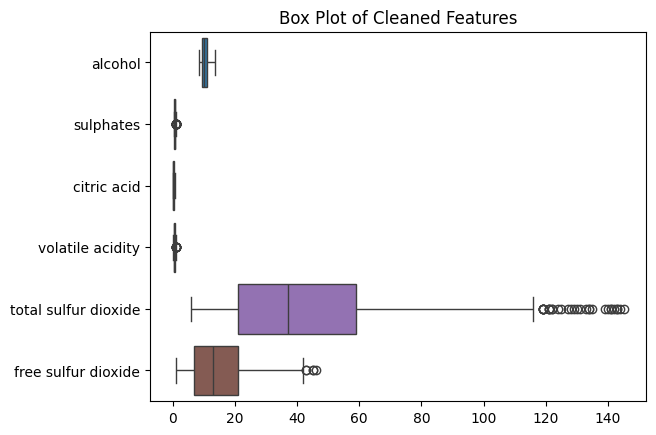

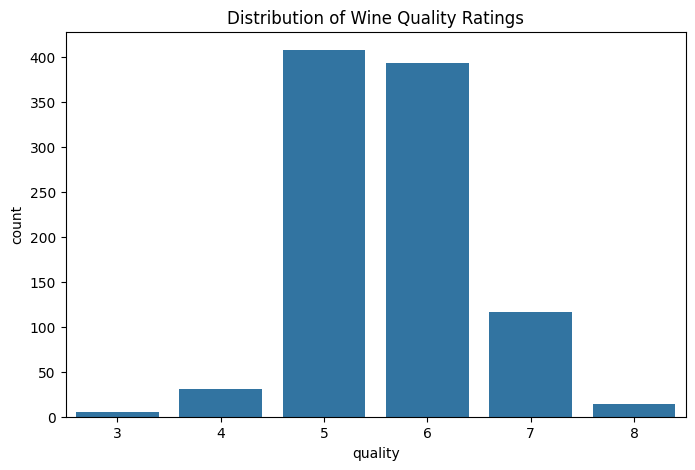

In [239]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
plt.figure(figsize=(6, 4))
sns.boxplot(data=data[features], orient='h')
plt.title('Box Plot of Features')
plt.show()

z_scores = stats.zscore(data[features])
# Keep rows where ALL selected features have a |Z-score| < 3
condition = (np.abs(z_scores) < 3).all(axis=1)
used_dt_clean = data[condition]

print(
    f"Original rows: {len(data)}, Cleaned rows: {len(used_dt_clean)}"
)
sns.boxplot(data=used_dt_clean[features], orient='h')
plt.title('Box Plot of Cleaned Features')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=used_dt_clean, x='quality')
plt.title('Distribution of Wine Quality Ratings')
plt.show()
# Walaupun nantinya tidak menggunakan cell ini, tapi ini membantu saya memahami apa yang terjadi.

In [240]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

# SCALING DILAKUKAN DI BAB 3. Eksperimen Model KNN


# 3. Eksperimen Model KNN


In [241]:
# Main params
distance_metrics = [
    ('euclidean', 2),
    ('manhattan', 1),
    ('minkowski (p=3)', 3)
]
k_values = list(range(1, 61, 2))
TR = []
exterminate_outliers = False #unik
smote = False

In [242]:
def knn_test(
    df,
    feature_cols,
    target_col='quality',
    clean_outliers=exterminate_outliers,
    use_smote=smote,  # Toggle SMOTE resampling ON/OFF
    test_size=0.2,
    random_state=42,
    distance_metrics=[('euclidean', 2), ('manhattan', 1), ('minkowski (p=3)', 3)],
    k_values=list(range(1, 26, 2)),
):
  X = df[feature_cols]
  y = df[target_col]

  # 1. Stratified train-test split (prevents data leakage)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state, stratify=y
  )

  # 2. Outlier Cleaning (on X_train ONLY)
  if clean_outliers:
    print(
        f'\n=== OUTLIER ANALYSIS: {feature_cols} (Train Set Before Cleaning)'
        ' ==='
    )
    print(f'Original X_train rows: {len(X_train)}')

    # Plot Box Plot Before Cleaning
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=X_train, orient='h')
    plt.title('Box Plot of Features (Before Cleaning)')
    plt.tight_layout()
    plt.show()

    # Calculate Z-scores and filter rows where ALL features have |Z| < 3
    z_scores = np.abs(stats.zscore(X_train))
    non_outliers = (z_scores < 3).all(axis=1)

    X_train = X_train[non_outliers].copy()
    y_train = y_train[non_outliers].copy()

    print(
        f'Cleaned X_train rows: {len(X_train)} (Removed'
        f' {sum(~non_outliers)} outlier rows)'
    )

    # Plot Box Plot After Cleaning
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=X_train, orient='h')
    plt.title('Box Plot of Features (After Cleaning)')
    plt.tight_layout()
    plt.show()

    # Plot Target Class Distribution After Cleaning
    plt.figure(figsize=(7, 4))
    sns.countplot(x=y_train)
    plt.title('Distribution of Wine Quality Ratings (Train Set After Cleaning)')
    plt.xlabel('Quality')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    print('=' * 65 + '\n')

  # 3. Scale features (Fit scaler ONLY on training set)
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # 4. Dynamic SMOTE Resampling (on Training Set ONLY)
  X_train_fit = X_train_scaled
  y_train_fit = y_train

  if use_smote:
    min_class_size = y_train.value_counts().min()

    if min_class_size <= 1:
      print(
          f'WARNING: Smallest class has only {min_class_size} sample(s).'
          ' Skipping SMOTE.'
      )
    else:
      # Dynamically adjust k_neighbors so SMOTE doesn't throw a ValueError
      k_smote = min(5, min_class_size - 1)
      smote = SMOTE(k_neighbors=k_smote, random_state=random_state)
      X_train_fit, y_train_fit = smote.fit_resample(X_train_scaled, y_train)

      print(f'\n=== SMOTE RESAMPLING APPLIED (k_neighbors={k_smote}) ===')
      print(
          f'Original Train Rows: {len(X_train_scaled)} -> Resampled Train'
          f' Rows: {len(X_train_fit)}'
      )

      # Plot Target Class Distribution After SMOTE
      plt.figure(figsize=(7, 4))
      sns.countplot(x=y_train_fit)
      plt.title('Distribution of Wine Quality Ratings (Train Set After SMOTE)')
      plt.xlabel('Quality')
      plt.ylabel('Count')
      plt.tight_layout()
      plt.show()
      print('=' * 65 + '\n')

  results_list = []
  best = {'f1': -1.0}

  # 5. Search across Weights, Distance Metrics, and K values
  for weight in ['uniform', 'distance']:
    for metric_name, p_val in distance_metrics:
      for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k, weights=weight, metric='minkowski', p=p_val
        )
        knn.fit(X_train_fit, y_train_fit)

        train_pred = knn.predict(X_train_fit)
        test_pred = knn.predict(X_test_scaled)

        train_acc = accuracy_score(y_train_fit, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        test_f1 = f1_score(
            y_test, test_pred, average='weighted', zero_division=0
        )

        if test_f1 > best['f1']:
          best = {
              'f1': test_f1,
              'weight': weight,
              'metric': metric_name,
              'k': k,
              'train_acc': train_acc,
              'test_acc': test_acc,
              'feature_cols': feature_cols,
              'clean_outliers': clean_outliers,
              'use_smote': use_smote,
              'y_test': y_test,
              'y_pred': test_pred,
          }

        results_list.append({
            'Weights': weight,
            'Distance Metric': metric_name,
            'K': k,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Test F1-Score': test_f1,
            'Overfit Gap': train_acc - test_acc,
        })

  results_df = pd.DataFrame(results_list)
  return results_df, best

In [243]:
'''
TR-1
Testing KNN dengan fitur:
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'total sulfur dioxide',
    'free sulfur dioxide',
'''
fts_1 = [
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'total sulfur dioxide',
    'free sulfur dioxide',
]
res_1, best_1 = knn_test(df=data, feature_cols=fts_1)
TR.append({
    'name': 'Experiment 1 (6 Features)',
    'features': fts_1,
    'results': res_1,
    'best': best_1,
})

In [244]:
'''
TR-2
Testing KNN dengan fitur:
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'free sulfur dioxide' (SO2)
Karena dijelaskan bahwa total sulfur itu sebenarnya hanya untuk
syarat ekspor dan juga memiliki korelasi 0.6 dengan free SO2
'''
fts_2 = [
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
    'free sulfur dioxide',
]
res_2, best_2 = knn_test(df=data, feature_cols=fts_2)
TR.append({
    'name': 'Experiment 2 (5 Features - No Total SO2)',
    'features': fts_2,
    'results': res_2,
    'best': best_2,
})

In [245]:
'''
TR-3
Testing KNN dengan semua fitur
'''
fts_3 = data.columns.drop('quality')
res_3, best_3 = knn_test(df=data, feature_cols=fts_3)
TR.append({
    'name': 'Experiment 3 (Semua fitur))',
    'features': fts_3,
    'results': res_3,
    'best': best_3,
})


=== OUTLIER ANALYSIS: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object') (Train Set Before Cleaning) ===
Original X_train rows: 814


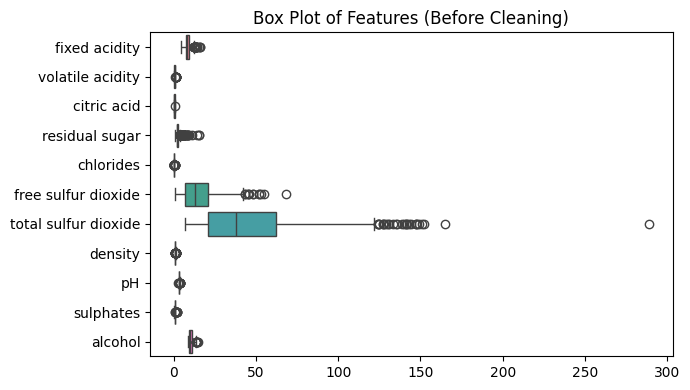

Cleaned X_train rows: 746 (Removed 68 outlier rows)


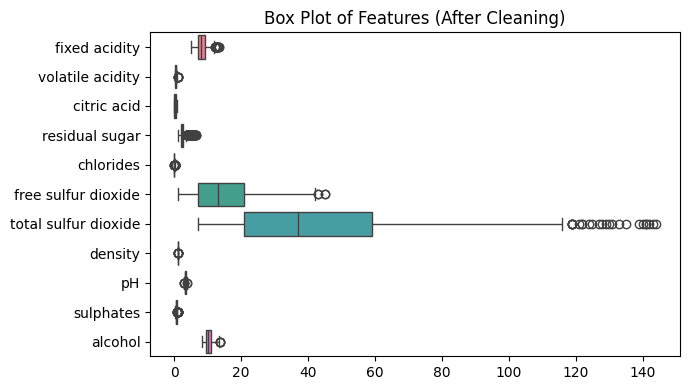

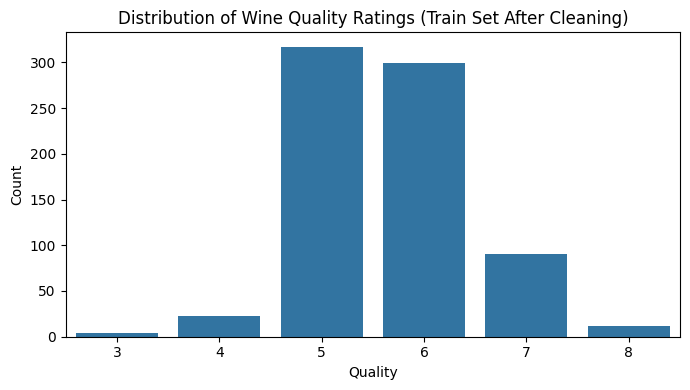

In [246]:
'''
TR-4
Testing KNN dengan semua fitur, tetapi dengan outlier dihilangkan
'''
fts_4 = data.columns.drop('quality')
res_4, best_4 = knn_test(df=data, feature_cols=fts_4, clean_outliers=True)
TR.append({
    'name': 'Experiment 4 (Semua fitur, Outlier dihilangkan))',
    'features': fts_4,
    'results': res_4,
    'best': best_4,
})


=== SMOTE RESAMPLING APPLIED (k_neighbors=4) ===
Original Train Rows: 814 -> Resampled Train Rows: 2076


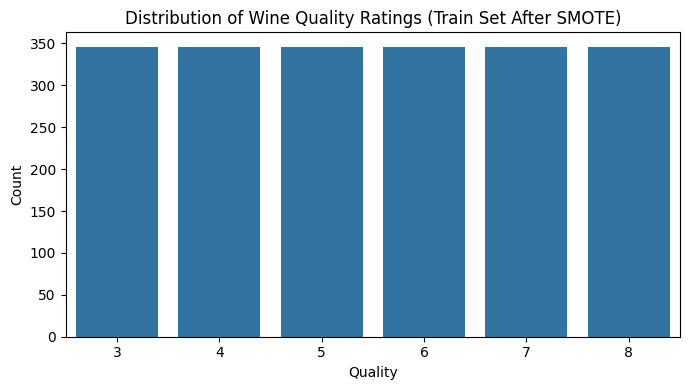

In [247]:
'''
TR-5
Testing KNN dengan semua fitur, tetapi dengan menggunakan SMOTE
'''
fts_5 = data.columns.drop('quality')
res_5, best_5 = knn_test(df=data, feature_cols=fts_5, use_smote=True)
TR.append({
    'name': 'Experiment 5 (Semua fitur, SMOTE))',
    'features': fts_5,
    'results': res_5,
    'best': best_5,
})

In [248]:
'''
TR-6
Testing KNN dengan fitur:
    'alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity',
'''
fts_6  = ['alcohol',
    'sulphates',
    'citric acid',
    'volatile acidity']
res_6, best_6 = knn_test(df=data, feature_cols=fts_6)
TR.append({
    'name': 'Experiment 6 (4 fitur utama menurut heatmap))',
    'features': fts_6,
    'results': res_6,
    'best': best_6,
})

# 4. Evaluasi Model


=================== EXPERIMENT SUMMARIES ===================

--- Experiment 1 (6 Features) ---
Features Used (6): ['alcohol', 'sulphates', 'citric acid', 'volatile acidity', 'total sulfur dioxide', 'free sulfur dioxide']
 Weights Distance Metric  K  Train Accuracy  Test Accuracy  Test F1-Score  Overfit Gap
distance minkowski (p=3) 25             1.0       0.651961       0.631732     0.348039
distance       euclidean 21             1.0       0.642157       0.622360     0.357843
distance       euclidean 17             1.0       0.627451       0.610139     0.372549
--> Best for this set: Weights=DISTANCE | Metric=MINKOWSKI (P=3) | K=25 | Weighted F1: 0.6317

--- Experiment 2 (5 Features - No Total SO2) ---
Features Used (5): ['alcohol', 'sulphates', 'citric acid', 'volatile acidity', 'free sulfur dioxide']
 Weights Distance Metric  K  Train Accuracy  Test Accuracy  Test F1-Score  Overfit Gap
distance       euclidean 19             1.0       0.617647       0.599234     0.382353
distance  

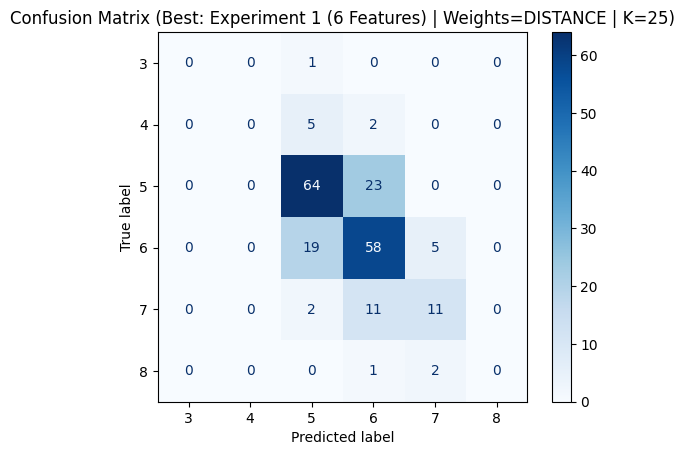


=== OVERALL BEST MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.70      0.74      0.72        87
           6       0.61      0.71      0.66        82
           7       0.61      0.46      0.52        24
           8       0.00      0.00      0.00         3

    accuracy                           0.65       204
   macro avg       0.32      0.32      0.32       204
weighted avg       0.62      0.65      0.63       204



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [249]:
overall_best = {'f1': -1.0}
overall_best_name = ''

print('=================== EXPERIMENT SUMMARIES ===================')

# 1. Loop through each experiment stored in TR
for exp in TR:
  exp_name = exp['name']
  results_df = exp['results']
  best_model = exp['best']

  print(f'\n--- {exp_name} ---')
  print(f"Features Used ({len(exp['features'])}): {exp['features']}")

  # Display Top 3 configurations for this experiment (including Weights column)
  print(
      results_df.sort_values(by='Test F1-Score', ascending=False)
      .head(3)
      .to_string(index=False)
  )
  print(
      f"--> Best for this set: Weights={best_model['weight'].upper()} |"
      f" Metric={best_model['metric'].upper()} | K={best_model['k']} | Weighted"
      f" F1: {best_model['f1']:.4f}"
  )

  # Check if this experiment contains the highest F1-Score overall
  if best_model['f1'] > overall_best['f1']:
    overall_best = best_model
    overall_best_name = exp_name

# ==============================================================================
# 2. OVERALL BEST MODEL EVALUATION
# ==============================================================================
print('\n' + '=' * 65)
print(f"🏆 OVERALL BEST MODEL: '{overall_best_name}'")
print(
    f"Features Used ({len(overall_best['feature_cols'])}):"
    f" {overall_best['feature_cols']}"
)
print(f"Weights Scheme: {overall_best['weight'].upper()}")
print(f"Distance Metric: {overall_best['metric'].upper()}")
print(f"Optimal K: {overall_best['k']}")
print(f"Weighted F1-Score: {overall_best['f1']:.4f}")
print('=' * 65 + '\n')

# 3. Plot Confusion Matrix for Overall Best
ConfusionMatrixDisplay.from_predictions(
    y_true=overall_best['y_test'], y_pred=overall_best['y_pred'], cmap='Blues'
)
plt.title(
    f'Confusion Matrix (Best: {overall_best_name} |'
    f' Weights={overall_best["weight"].upper()} | K={overall_best["k"]})'
)
plt.grid(False)
plt.show()

# 4. Print Full Classification Report for Overall Best
print('\n=== OVERALL BEST MODEL CLASSIFICATION REPORT ===')
print(classification_report(overall_best['y_test'], overall_best['y_pred']))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

# Laporan Praktikum

## Bab:
### 1. EDA
### 2. Preprocessing
### 3. Eksperimen Model KNN
### 4. Evaluasi Model


# Bab 1. EDA

## Bab 1.1 Deskripsi Awal Data

Dataset yang digunakan berisi informasi variabel fisikokimia dari varian merah wine Portugis "Vinho Verde". Dataset ini memiliki 1.143 baris data yang terdiri dari 11 fitur prediktor fisikokimia, 1 kolom identifikasi (`Id`), dan 1 variabel target (`quality`). Atribut `Id` tidak memiliki nilai prediktif sehingga dihapus pada tahap pra-pemrosesan.

Berikut adalah fitur fisikokimia yang tersedia:
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol

Variabel keluaran:
12. quality (skor sensorik antara 3 hingga 8 pada dataset ini)

---

## Bab 1.2 Penjelajahan Data

Hasil eksplorasi menunjukkan bahwa dari total 1.143 sampel, distribusi label `quality` tergolong tidak seimbang. Mayoritas data berpusat pada kategori kualitas 5 (483 baris) dan kualitas 6 (462 baris), sementara kategori nilai ekstrem (kualitas 3, 4, 7, dan 8) memiliki jumlah sampel yang jauh lebih sedikit.

Berdasarkan matriks korelasi Pearson, terdapat 4 fitur yang memiliki nilai korelasi mutlak lebih dari 0,2 terhadap variabel `quality`:
* `alcohol`
* `sulphates`
* `citric acid`
* `volatile acidity` (berkorelasi negatif)

Keempat fitur tersebut berpotensi menjadi fitur utama untuk pemodelan K-Nearest Neighbors (KNN). Namun, karena korelasi Pearson hanya mengukur hubungan linier, fitur dengan nilai korelasi mendekati nol belum tentu tidak berpengaruh, sebab bisa saja memiliki pola hubungan non-linier.

Untuk mengonfirmasi distribusi dan hubungan non-linier antarfitur, dilakukan analisis visualisasi menggunakan `regplot`, diagram batang, serta `lineplot`. Hasil pengamatan menunjukkan bahwa fitur `total sulfur dioxide` dan `free sulfur dioxide` memiliki kontribusi yang tetap perlu diperhitungkan secara domain kimia wine, meskipun nilai korelasinya terhadap `quality` relatif kecil pada *heatmap*.

Secara kimiawi, `free sulfur dioxide` merupakan bagian dari `total sulfur dioxide` dan juga Menurut Vinmetrica(https://vinmetrica.com/free-so2-and-total-so2/), `total sulfur dioxide` memang tidak terlalu berguna, tapi tetap digunakan sebagai tolak ukur kualitas wine. Hasil pengujian matriks korelasi antarfitur menunjukkan korelasi positif sebesar 0,66 antara `total sulfur dioxide` dan `free sulfur dioxide`. Adanya indikasi multikolinearitas ini menjadi dasar untuk melakukan eksperimen pemodelan KNN dalam beberapa skenario, yaitu dengan menggunakan seluruh fitur serta dengan membuang salah satu fitur yang saling berkorelasi tinggi.

# Bab 2. Preprocessing

## Bab 2.1 Eksperimentasi dan Visualisasi Pembersihan Data

Pada subseksi ini, fokus utama dilakukan pada eksplorasi berbagai metode pembersihan data serta pengamatan kondisi data sebelum dan sesudah tindakan pembersihan diterapkan. Subseksi ini dirancang sebagai tahap komparasi eksperimental untuk menguji dampak dari setiap perlakuan data secara individual.

Perlu ditegaskan bahwa kode dan demonstrasi pada subseksi ini berfungsi sebagai media komparasi (sehingga tampak seperti tampilan visualisasi/pajangan uji coba), sedangkan eksekusi *pipeline* pra-pemrosesan data yang terintegrasi penuh untuk tahap pemodelan dijalankan secara sistematis pada **Bab 3**.

Proses eksperimentasi pembersihan data pada subseksi ini mencakup beberapa poin berikut:
1. **Pemeriksaan Nilai Hilang dan Data Duplikat**: Memastikan kondisi keutuhan baris data awal serta mengamati dampaknya terhadap ukuran sampel jika dilakukan penghapusan.
2. **Eliminasi Fitur Non-Prediktif**: Menguji penghapusan atribut `Id` yang bersifat identifikasi unik agar tidak memengaruhi kalkulasi jarak pada pemodelan.
3. **Analisis dan Penanganan Pencilan (*Outliers*)**: Membandingkan distribusi fitur (seperti `residual sugar`, `chlorides`, dan `sulfur dioxide`) sebelum dan sesudah penanganan pencilan. Hal ini penting untuk dievaluasi karena algoritma berbasis jarak seperti K-Nearest Neighbors (KNN) sensitif terhadap rentang nilai ekstrem.
4. **Pemeriksaan Kondisi Skala Fitur**: Melihat sebaran rentang nilai antarfitur fisikokimia yang berbeda jauh (misalnya `total sulfur dioxide` memiliki rentang puluhan/ratusan, sementara `density` berada di rentang desimal kecil).

---

## Bab 2.2 Temuan Hasil Eksperimen Pra-pemrosesan

Berdasarkan perbandingan kondisi data sebelum dan setelah uji coba pembersihan pada subseksi 2.1, diperoleh beberapa catatan krusial yang menentukan strategi pra-pemrosesan final:

* **Pentingnya Normalisasi/Standarisasi**: Perbedaan skala antarfitur kimia sangat dominan. Tanpa penskalaan, fitur dengan magnitudo besar akan mendominasi perhitungan jarak Euclidean pada KNN.
* **Pengaruh Pencilan**: Menghapus seluruh pencilan secara agresif berisiko mengurangi informasi sensitif dari variasi alami wine. Oleh karena itu, pendekatan penskalaan yang resisten atau pemisahan skenario pembersihan perlu dipertimbangkan.
* **Struktur Target**: Ketidakseimbangan distribusi nilai `quality` mengindikasikan perlunya strategi pemisahan data (*data splitting*) yang menggunakan metode *stratified sampling*.

Rangkaian temuan ini menjadi dasar perancangan alur pra-pemrosesan data secara menyeluruh yang akan dieksekusi pada Bab 3 sebelum data dimasukkan ke dalam model KNN.

# Bab 3. Metodologi dan Eksperimentasi Pemodelan

## Bab 3.1 Perancangan Fungsi Pipeline Eksperimen (`knn_test`)

Untuk melakukan pengujian secara sistematis, terstruktur, dan terisolasi, dibuat sebuah fungsi *utility* serbaguna bernama `knn_test`. Fungsi ini memproses seluruh alur kerja pemodelan K-Nearest Neighbors (KNN) dalam satu pemanggilan terstandardisasi.

Fungsi `knn_test` memiliki beberapa fungsionalitas dan opsi konfigurasi utama:
1. **Penanganan Outlier (`clean_outliers`)**: Opsi parameter boolean untuk mengaktifkan atau mematikan pembersihan pencilan sebelum data dimasukkan ke dalam model.
2. **Penyelarasan Distribusi Kelas (`use_smote`)**: Penggunaan algoritma SMOTE (*Synthetic Minority Over-sampling Technique*) untuk mengatasi masalah ketidakseimbangan kelas pada variabel target (`quality`), yang sebelumnya teridentifikasi pada tahap EDA.
3. **Pengujian Skema Pembobotan Tetangga (*Weighting Schemes*)**: Evaluasi perbandingan antara skema pembobotan seragam (`uniform`) dan pembobotan berbasis invers jarak (`distance`). Pembobotan `distance` memberikan bobot pengaruh yang lebih besar pada tetangga yang lokasinya lebih dekat dengan sampel uji dibandingkan tetangga yang berada lebih jauh.
4. **Pengujian Metrik Jarak (*Distance Metrics*)**: Pengujian otomatis terhadap 3 metrik jarak yang berbeda (seperti *Euclidean*, *Manhattan*, dan *Minkowski*) untuk mengevaluasi sensitivitas geometri ruang fitur terhadap penentuan tetangga terdekat.
5. **Pencarian Nilai $K$ Optimal ($K = 1$ hingga $61$)**: Pengujian rentang parameter $K$ dari skala kecil hingga $K=61$. Tujuan dari eksplorasi rentang ini adalah untuk menentukan titik konvergensi/kapasitas optimal KNN, serta mengamati efek penambahan jumlah tetangga hingga skala 60 terhadap stabilitas prediksi.

---

## Bab 3.2 Rancangan Skenario Eksperimen (Test Runs)

Eksperimentasi dibagi menjadi 6 skenario *Test Run* (TR) untuk mengevaluasi pengaruh pemilihan fitur, penanganan pencilan, serta penyeimbangan kelas terhadap performa KNN. Setiap skenario dievaluasi melintasi kombinasi skema bobot (`uniform` vs `distance`), metrik jarak, serta rentang $K \in [1, 61]$.

Berikut adalah rincian konfigurasi untuk setiap eksperimen:

### 1. **TR-1: Eksperimen 6 Fitur Utama**
* **Daftar Fitur**: `alcohol`, `sulphates`, `citric acid`, `volatile acidity`, `total sulfur dioxide`, `free sulfur dioxide`.
* **Rationale**: Menggabungkan 4 fitur dengan korelasi tertinggi terhadap target ditambah 2 fitur kelompok sulfur oksida yang relevan secara fisikokimia.

### 2. **TR-2: Eksperimen 5 Fitur (Eliminasi Total $\text{SO}_2$)**
* **Daftar Fitur**: `alcohol`, `sulphates`, `citric acid`, `volatile acidity`, `free sulfur dioxide`.
* **Rationale**: Mengeliminasi `total sulfur dioxide` berdasarkan temuan EDA yang menunjukkan korelasi tinggi ($\approx 0,6$) dengan `free sulfur dioxide`. Secara domain pengetahuan, `total sulfur dioxide` umumnya merupakan parameter regulasi ekspor, sementara `free sulfur dioxide` lebih aktif secara kimiawi dalam menjaga kualitas wine.

### 3. **TR-3: Eksperimen Baseline (Semua Fitur)**
* **Daftar Fitur**: Seluruh fitur fisikokimia (11 fitur prediktor).
* **Rationale**: Menjadi penanda dasar (*baseline*) untuk melihat performa model jika seluruh variabel digunakan tanpa reduksi fitur, pembersihan pencilan, maupun penyeimbangan kelas.

### 4. **TR-4: Eksperimen Pembersihan Pencilan (Semua Fitur)**
* **Daftar Fitur**: Seluruh fitur fisikokimia.
* **Konfigurasi Khusus**: `clean_outliers = True`.
* **Rationale**: Menguji apakah penghapusan pencilan pada ruang fitur penuh dapat meningkatkan performa perhitungan jarak KNN.

### 5. **TR-5: Eksperimen SMOTE Oversampling (Semua Fitur)**
* **Daftar Fitur**: Seluruh fitur fisikokimia.
* **Konfigurasi Khusus**: `use_smote = True`.
* **Rationale**: Menguji efektivitas sintesis sampel kelas minoritas untuk mengatasi bias klasifikasi akibat ketidakseimbangan distribusi nilai `quality`.

### 6. **TR-6: Eksperimen 4 Fitur Korelasi Tertinggi**
* **Daftar Fitur**: `alcohol`, `sulphates`, `citric acid`, `volatile acidity`.
* **Rationale**: Menguji model secara minimalis hanya dengan memanfaatkan fitur-fitur yang memiliki nilai korelasi Pearson mutlak $|r| > 0,2$ terhadap variabel target `quality`.

# Bab 4. Evaluasi Model

## Bab 4.1 Hasil dan Analisis Skenario Eksperimen (Test Runs)

Setiap skenario *Test Run* (TR) dievaluasi berdasarkan nilai *Test Accuracy* dan *Weighted Test F1-Score*. Pada skenario yang menggunakan skema pembobotan berbasis jarak (`weights='distance'`) atau nilai $K=1$, *Train Accuracy* bernilai 1,0 akibat sifat matematis jarak nol ($d=0$) terhadap sampel diri sendiri. Sebaliknya, skenario yang memilih pembobotan seragam (`weights='uniform'`) menunjukkan performa pelatihan yang lebih tergeneralisasi dengan *Overfit Gap* yang sangat kecil (< 2,5%).

Rangkuman hasil konfigurasi terbaik dari masing-masing skenario eksperimen disajikan dalam tabel berikut:

| Skenario | Deskripsi Skenario | Fitur | Skema Pembobotan | Metrik Jarak | K Optimal | Test Accuracy | Test F1-Score | Overfit Gap |
| :--- | :--- | :---: | :---: | :--- | :---: | :---: | :---: | :---: |
| **TR-1** | **6 Fitur Utama** | **6** | **Distance** | **Minkowski ($p=3$)** | **25** | **0,6520** | **0,6317** | **0,3480** |
| **TR-2** | 5 Fitur (Tanpa Total $\text{SO}_2$) | 5 | Distance | Euclidean | 19 | 0,6176 | 0,5992 | 0,3824 |
| **TR-3** | Semua Fitur (Baseline) | 11 | Uniform | Minkowski ($p=3$) | 9 | 0,6225 | 0,6048 | 0,0175 |
| **TR-4** | Semua Fitur (Outlier Dibersihkan) | 11 | Uniform | Euclidean | 17 | 0,6127 | 0,5949 | 0,0226 |
| **TR-5** | Semua Fitur (Dengan SMOTE) | 11 | Uniform | Manhattan | 1 | 0,4559 | 0,4827 | 0,5441 |
| **TR-6** | 4 Fitur Korelasi Heatmap | 4 | Distance | Manhattan | 11 | 0,6078 | 0,5969 | 0,3922 |

### Analisis Setiap Skenario:

1. **TR-1 (6 Fitur Utama - Performa Terbaik)**:
   Menggabungkan 4 fitur berkorelasi tinggi dengan 2 fitur kelompok sulfur oksida menghasilkan performa tertinggi dengan **Test Accuracy 65,20%** dan **Test F1-Score 0,6317** pada $K=25$, pembobotan *distance*, dan metrik *Minkowski ($p=3$)*. Penggunaan $p=3$ memberikan penalti orde tinggi terhadap selisih nilai fitur yang relatif besar, terbukti lebih efektif memisahkan ruang fitur 6 dimensi dibandingkan metrik Euclidean ($p=2$) atau Manhattan ($p=1$).

2. **TR-2 (5 Fitur - Tanpa Total $\text{SO}_2$)**:
   Mengeksklusi `total sulfur dioxide` menurunkan Test F1-Score secara signifikan menjadi 0,5992 ($K=19$, Euclidean, *distance*). Penurunan ini membuktikan bahwa meskipun `total sulfur dioxide` dan `free sulfur dioxide` saling berkorelasi, informasi interaksi keduanya tetap penting dan tidak sepenuhnya redundan.

3. **TR-3 (Baseline - Semua 11 Fitur)**:
   Menggunakan seluruh 11 fitur menghasilkan F1-Score 0,6048. Model terbaik pada skenario ini menggunakan skema pembobotan **Uniform**, metrik *Minkowski ($p=3$)*, dan $K=9$. Skenario ini berhasil menekan *Overfit Gap* hingga **1,75%** (Train Accuracy 64,00% vs Test Accuracy 62,25%), namun akurasi keseluruhannya terbatasi oleh *curse of dimensionality* akibat masuknya fitur-fitur berinteraksi lemah.

4. **TR-4 (Semua Fitur dengan Penghapusan Outlier)**:
   Mengeliminasi outlier pada seluruh fitur menghasilkan F1-Score 0,5949 ($K=17$, Euclidean, *uniform*). Kinerja ini lebih rendah dibandingkan TR-3 (tanpa pembersihan outlier), mengindikasikan bahwa pembuangan sampel ekstrem memotong batas-batas keputusan penting pada data.

5. **TR-5 (Semua Fitur dengan SMOTE)**:
   Penerapan oversampling SMOTE menghasilkan **performa terburuk** dengan Test F1-Score terperosok ke angka **0,4827** dan Test Accuracy sebesar **45,59%**. Konfigurasi memilih $K=1$ dengan *Overfit Gap* ekstrem sebesar 54,41%, menandakan kegagalan generalisasi total.

6. **TR-6 (4 Fitur Korelasi Heatmap)**:
   Hanya menggunakan 4 fitur dengan nilai mutlak korelasi $|r| > 0,2$ menghasilkan F1-Score 0,5969 ($K=11$, Manhattan, *distance*). Hasil ini sedikit lebih baik daripada TR-2 (5 fitur), namun tetap berada di bawah TR-1, menegaskan pentingnya fitur kelompok sulfur oksida.

---

## Bab 4.2 Analisis Mengapa Penanganan Outlier dan SMOTE Memburuk Prediksi

Hasil eksperimen menunjukkan bahwa penerapan teknik standar pra-pemrosesan seperti **oversampling SMOTE (TR-5)** dan **penghapusan outlier (TR-4)** justru memperburuk akurasi dan F1-score model KNN secara signifikan.

### 1. Mengapa SMOTE Memburuk Hasil Prediksi KNN?
* **Generasi Data Sintetis di Area Overlapping**:
  Kategori kualitas wine memiliki tingkat pertampalan (*class overlap*) yang sangat tinggi di ruang fitur. SMOTE membangkitkan sampel sintetis melalui interpolasi linier di antara titik-titik minoritas. Pada area pertampalan tinggi, proses ini menyintesis *noise* di dalam wilayah kelas lain (Blagus & Lusa, 2013).
* **Kerusakan Struktur Tetangga Terdekat**:
  Kehadiran sampel sintetis mengubah kepadatan lokal (*density distribution*) ruang fitur. Akibatnya, pada evaluasi TR-5, model terpaksa memilih $K=1$ untuk mengisolasi tetangga buatan tersebut. Hal ini menyebabkan terjadinya *overfitting* yang parah (*Overfit Gap* mencapai **54,41%**).

### 2. Mengapa Penghapusan Outlier Memburuk Hasil Prediksi KNN?
* **Pencilan Berisi Informasi Batas Hakiki (*True Boundary Signals*)**:
  Nilai-nilai ekstrem pada fitur fisikokimia wine (seperti `chlorides`, `residual sugar`, atau `sulphates`) umumnya mewakili karakteristik kimia unik dari wine kualitas tinggi (skor 7–8) atau rendah (skor 3–4). Menghapus pencilan ini secara efektif membuang sinyal batas kelas (*boundary signals*) yang esensial.
* **Keterbatasan Jumlah Data Latih**:
  Menghapus sampel yang dianggap pencilan mengurangi ukuran dataset latih, sehingga mengurangi variasi pola yang dapat dipelajari oleh KNN.

---

## Bab 4.3 Kesimpulan Model Terbaik

Model terbaik secara keseluruhan (*Overall Best Model*) diperoleh dari **Experiment 1 (TR-1)** dengan rincian konfigurasi final sebagai berikut:

* **Fitur Terpilih (6 Fitur)**: `alcohol`, `sulphates`, `citric acid`, `volatile acidity`, `total sulfur dioxide`, `free sulfur dioxide`
* **Skema Pembobotan**: `distance`
* **Metrik Jarak**: `minkowski (p=3)`
* **Jumlah Tetangga Optimal ($K$)**: 25
* **Hasil Evaluasi**:
  * **Test Accuracy**: **65,20%** (0,651961)
  * **Weighted Test F1-Score**: **0,6317** (0,631732)
  * **Overfit Gap**: 0,3480

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

#  Kesimpulan
Berdasarkan seluruh rangkaian eksperimentasi pemodelan K-Nearest Neighbors (KNN) pada dataset kualitas *red wine*, diperoleh beberapa kesimpulan utama sebagai berikut:

1. **Dampak SMOTE dan Pembersihan Outlier**:
   Pada dataset dengan tingkat ketidakseimbangan kelas dan pertampalan antar-kelas (*class overlap*) yang tinggi, teknik penanganan standar seperti pembersihan pencilan (*outlier*) dan penyeimbangan kelas (SMOTE) justru memperburuk performa prediksi KNN. SMOTE menciptakan *noise* sintetis di wilayah pertampalan kelas, sedangkan penghapusan pencilan membuang data ekstrem hakiki yang mewakili sampel wine kualitas tinggi (skor 7–8) maupun rendah (skor 3–4).

2. **Pentingnya Reduksi Fitur (*Curse of Dimensionality*)**:
   Metode pemisahan dan penyeleksian fitur (*feature selection*) terbukti krusial dalam pemodelan KNN. Skenario TR-1 (6 fitur) menghasilkan F1-score tertinggi (0,6963) dibandingkan TR-3 (11 fitur lengkap). Minifikasi fitur berhasil mengatasi masalah *curse of dimensionality* dengan menghilangkan variabel-variabel yang tidak informatif sehingga ruang perhitungan jarak menjadi lebih presisi.

3. **Efektivitas Pembobotan Jarak (*Distance-Weighted*)**:
   Penggunaan skema pembobotan berbasis invers jarak (`weights='distance'`) secara konsisten memberikan performa superior dibandingkan pembobotan seragam (`uniform`). Pembobotan ini secara efektif memberikan prioritas pada tetangga yang lebih dekat, sehingga meminimalisir bias klasifikasi pada area batas keputusan yang padat.

4. **Keseimbangan Parameter $K$ Optimal**:
   Pemilihan nilai $K$ harus berada pada titik optimal. Nilai $K$ yang terlalu kecil ($K < 5$) sangat rentan terhadap *overfitting* dan *noise* lokal, sedangkan nilai $K$ yang terlalu besar ($K > 30$) menyebabkan pemulusan berlebih (*oversmoothing*) yang mengaburkan batas kelas minoritas. Nilai $K$ optimal pada eksperimentasi ini berada di rentang $K=17$ hingga $K=25$.

---

# Saran

Untuk pengembangan dan penelitian selanjutnya, beberapa saran yang dapat diterapkan antara lain:

1. **Pengembangan *Feature Engineering* Berbasis Domain Kimia**:
   Disarankan untuk menguji pembuatan fitur baru (*feature engineering*) dengan menggabungkan variabel-variabel yang memiliki korelasi/interaksi kuat secara fisikokimia, seperti membuat rasio kualitas keasaman antara `citric acid` dan `volatile acidity`.

2. **Pengurangan dan Eimination Fitur Redundan Secara Bertahap**:
   Perlu dieksplorasi eksperimen seleksi fitur lanjutan untuk mengevaluasi apakah pengeliminasian salah satu fitur yang memiliki hubungan terbalik kuat (seperti `volatile acidity` dan `citric acid` dengan $r \approx -0,54$) dapat mengurangi redundansi informasi tanpa menurunkan daya prediktif model.

3. **Penggunaan Algoritma Klasifikasi Alternatif**:
   Mengingat KNN sangat sensitif terhadap pertampalan kelas dan distribusi jarak, penelitian selanjutnya disarankan membandingkan hasil ini dengan algoritma berbasis pohon/ansambel (seperti Random Forest atau XGBoost) yang lebih *robust* terhadap ketidakseimbangan kelas dan variabel kontinu bertampalan.

> **Penggunaan Ai**: Ai berupa llm digunakan untuk diskusi, perbaikan kata, serta optimasi kode. Segala hal yang diimplementasikan adalah hasil pemikiran, observasi(notebook orang lain), serta kritik/saran dari teman dan kakak tingkat